# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/russelfordguinoo-oss/Russel-Repository-/blob/main/work/notebooks/capstone.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## Setup and imports

This section initializes the analysis environment and defines the random seed for reproducibility.

In [71]:
# ==========================================
# 1. SETUP & IMPORTS
# ==========================================

import numpy as np
import pandas as pd

from datasets import load_dataset
from huggingface_hub import login

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

print("Setup complete.")
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

Setup complete.
NumPy: 2.5.2
Pandas: 2.2.2


In [72]:
login()

## 1. Question

*The research question and the decision it supports.*

## Research question

What characteristics are associated with strong-performing pages?

**Decision supported:**  
Help a content team understand what characteristics are associated with strong-performing pages and use those characteristics to prioritize diagnostic review.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

## Data

The analysis uses the FlyRank `internship-lanes` dataset, specifically the `ranking_lifecycle` subset, containing 205,749 page observations and 34 columns.

The unit of analysis is the content/page. The analysis uses 30-day performance fields. `impressions_30d` and `clicks_30d` are complete in the full dataset. `sessions_30d` is missing for 26.04% of rows, so it was excluded from the benchmark to avoid requiring a partially observed metric.

The strong-page benchmark uses the 90th percentile of `impressions_30d` (2,080) and `clicks_30d` (8). Pages meeting both thresholds are labeled strong: 14,972 pages, or 7.28% of the dataset.

Pseudonymous IDs are used only for grouping or identifying records. Client names, domains, URLs, private queries, credentials, and other client-identifying information are excluded from the public work.

In [73]:
# ==========================================
# 2. DATA LOADING
# ==========================================

full_ds = load_dataset(
    "FlyRank/internship-lanes",
    "ranking_lifecycle",
    split="train"
)

full_df = full_ds.to_pandas()

print("Dataset shape:", full_df.shape)
print("Rows:", len(full_df))
print("Columns:", len(full_df.columns))

Dataset shape: (205749, 34)
Rows: 205749
Columns: 34


## Data audit

Inspect the dataset structure, missingness, and identifier counts before modeling.

In [74]:
# ==========================================
# 3. DATA AUDIT
# ==========================================

print("Unique clients:", full_df["client_hash_id"].nunique())
print("Unique content pages:", full_df["content_hash_id"].nunique())

print("\nMissingness by column (%):")

missingness = (
    full_df.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print(missingness.to_string())

Unique clients: 54
Unique content pages: 205749

Missingness by column (%):
ai_traffic_pct_30d           49.760631
engagement_rate_30d          49.760631
scroll_rate_30d              49.759659
engaged_sessions_30d         26.044841
scroll_events_30d            26.044841
users_30d                    26.044841
sessions_30d                 26.044841
ai_sessions_30d              26.044841
pageviews_30d                26.044841
main_intent                   7.303559
search_volume                 6.939037
keyword_hash_id               6.533689
public_url_path_depth         0.163792
public_url_hash_id            0.163792
content_hash_id               0.000000
client_hash_id                0.000000
keyword_token_count           0.000000
public_url_char_count         0.000000
client_has_ga4                0.000000
client_has_gsc                0.000000
content_age_days              0.000000
content_created_at            0.000000
content_type                  0.000000
content_title_token_count  

In [75]:
audit_cols = [
    "impressions_30d",
    "clicks_30d",
    "sessions_30d",
    "client_has_ga4",
]

print("Focused availability audit:")
print(
    full_df[audit_cols]
    .isna()
    .mean()
    .mul(100)
    .round(2)
    .rename("missing_pct")
)

Focused availability audit:
impressions_30d     0.00
clicks_30d          0.00
sessions_30d       26.04
client_has_ga4      0.00
Name: missing_pct, dtype: float64


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

## Strong-page benchmark and target

A page is labeled strong when both its 30-day impressions and 30-day clicks are at or above their respective 90th-percentile thresholds.

## Feature contract

The classifier uses 10 page/content characteristics:

- `keyword_char_count`
- `keyword_token_count`
- `public_url_char_count`
- `public_url_path_depth`
- `content_title_char_count`
- `content_title_token_count`
- `search_volume`
- `content_type`
- `main_intent`
- `content_age_days`

Performance variables used to construct the label, other performance-derived fields, and pseudonymous identifiers are excluded from predictive features.

## Leakage controls

`impressions_30d` and `clicks_30d` are excluded from model features because they directly define the `is_strong` label. Other performance and performance-derived fields are also excluded, including CTR, position, sessions, pageviews, engagement measures, AI traffic measures, performance tiers, and `health_score`.

Pseudonymous IDs are not used as predictive features. `client_hash_id` is used only for grouped validation, while `content_hash_id` is used only to identify records in the diagnostic ranking. `content_created_at` is excluded because `content_age_days` already represents the page-age information.

## Leakage controls

`impressions_30d` and `clicks_30d` are excluded from model features because they directly define the `is_strong` label. Other performance and performance-derived fields are also excluded, including CTR, position, sessions, pageviews, engagement measures, AI traffic measures, performance tiers, and `health_score`.

Pseudonymous IDs are not used as predictive features. `client_hash_id` is used only for grouped validation, while `content_hash_id` is used only to identify records in the diagnostic ranking. `content_created_at` is excluded because `content_age_days` already represents the page-age information.

## Validation design

The final evaluation uses a stratified group split by `client_hash_id`. All pages from a client remain entirely in either the training set or the held-out test set, preventing client overlap between the two sets.

The resulting split contains 156,000 training pages from 43 clients and 49,749 test pages from 11 clients, with zero client overlap. Five-fold `StratifiedGroupKFold` is used within the training data for out-of-fold threshold selection. The held-out test set is reserved for final evaluation.

## Preprocessing

Numeric features are median-imputed and standardized. Categorical features are imputed with the most frequent category and one-hot encoded. All preprocessing is fitted inside the modeling pipeline using training data only.

## Baseline and models

The baseline always predicts the majority class, `not strong`. This provides a transparent reference for an imbalanced target whose overall strong-page rate is 7.28%.

Logistic Regression is the primary model because it provides interpretable coefficients and probability scores. Random Forest is used as a robustness comparison to test whether nonlinear relationships improve discrimination using the same target, features, client-grouped split, and evaluation set.

## Threshold selection

Classification thresholds are selected using five-fold stratified group out-of-fold predictions from the training data only, with F1 used as the selection criterion. The selected threshold is then frozen and applied once to the untouched test set for final evaluation.

In [76]:
# ==========================================
# 4. TARGET / BENCHMARK
# ==========================================

impressions_90 = full_df["impressions_30d"].quantile(0.90)
clicks_90 = full_df["clicks_30d"].quantile(0.90)

full_df["is_strong"] = (
    (full_df["impressions_30d"] >= impressions_90)
    & (full_df["clicks_30d"] >= clicks_90)
)

strong_count = int(full_df["is_strong"].sum())
total_count = len(full_df)
strong_rate = full_df["is_strong"].mean()

print(f"Impressions 90th percentile: {impressions_90:.0f}")
print(f"Clicks 90th percentile: {clicks_90:.0f}")
print(f"Strong pages: {strong_count:,}")
print(f"Strong-page rate: {strong_rate * 100:.2f}%")

Impressions 90th percentile: 2080
Clicks 90th percentile: 8
Strong pages: 14,972
Strong-page rate: 7.28%


In [77]:
print(
    full_df["is_strong"]
    .value_counts()
    .rename({
        True: "Strong",
        False: "Not strong"
    })
)

is_strong
Not strong    190777
Strong         14972
Name: count, dtype: int64


## Feature contract

The classifier uses only page/content characteristics. Performance variables used to construct the strong-page label, performance-derived fields, and pseudonymous identifiers are excluded from model features.

In [78]:
# ==========================================
# 5. FEATURE CONTRACT
# ==========================================

feature_cols = [
    "keyword_char_count",
    "keyword_token_count",
    "public_url_char_count",
    "public_url_path_depth",
    "content_title_char_count",
    "content_title_token_count",
    "search_volume",
    "content_type",
    "main_intent",
    "content_age_days",
]

numeric_features = [
    "keyword_char_count",
    "keyword_token_count",
    "public_url_char_count",
    "public_url_path_depth",
    "content_title_char_count",
    "content_title_token_count",
    "search_volume",
    "content_age_days",
]

categorical_features = [
    "content_type",
    "main_intent",
]

excluded_identifier_cols = [
    "client_hash_id",
    "content_hash_id",
    "keyword_hash_id",
    "public_url_hash_id",
    "content_title_hash_id",
]

excluded_performance_cols = [
    "impressions_30d",
    "clicks_30d",
    "ctr_30d",
    "avg_position_30d",
    "pageviews_30d",
    "sessions_30d",
    "users_30d",
    "engaged_sessions_30d",
    "ai_sessions_30d",
    "scroll_events_30d",
    "engagement_rate_30d",
    "scroll_rate_30d",
    "ai_traffic_pct_30d",
    "impression_tier",
    "position_tier",
    "health_score",
]

excluded_duplicate_time_col = [
    "content_created_at"
]

print("Model features:", len(feature_cols))
print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Model features: 10
Numeric features: 8
Categorical features: 2


## Client-grouped validation

Training and test observations are split by `client_hash_id` so that no client appears in both sets. Stratified grouping is used to keep the strong-page proportion reasonably similar across the two sets.

In [79]:
# ==========================================
# 6. GROUPED TRAIN / TEST SPLIT
# ==========================================

sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

train_idx, test_idx = next(
    sgkf.split(
        full_df,
        full_df["is_strong"],
        groups=full_df["client_hash_id"]
    )
)

train_df = full_df.iloc[train_idx].copy()
test_df = full_df.iloc[test_idx].copy()

train_clients = set(train_df["client_hash_id"])
test_clients = set(test_df["client_hash_id"])

client_overlap = train_clients.intersection(test_clients)

print("Train rows:", len(train_df))
print("Test rows:", len(test_df))
print("Train clients:", len(train_clients))
print("Test clients:", len(test_clients))
print(
    "Train strong rate:",
    f"{train_df['is_strong'].mean() * 100:.2f}%"
)
print(
    "Test strong rate:",
    f"{test_df['is_strong'].mean() * 100:.2f}%"
)
print("Client overlap:", len(client_overlap))

Train rows: 156000
Test rows: 49749
Train clients: 43
Test clients: 11
Train strong rate: 6.89%
Test strong rate: 8.49%
Client overlap: 0


## Preprocessing pipeline

Numeric features use median imputation and standardization. Categorical features use most-frequent imputation and one-hot encoding. All preprocessing is fitted within the training pipeline to avoid test-set leakage.

In [80]:
# ==========================================
# 7. PREPROCESSING
# ==========================================

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features),
])

X_train = train_df[feature_cols]
y_train = train_df["is_strong"]

X_test = test_df[feature_cols]
y_test = test_df["is_strong"]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (156000, 10)
X_test: (49749, 10)


## Baseline

The baseline always predicts the majority class, `not strong`. Because only 7.28% of the full dataset is strong, accuracy alone is not an adequate measure of usefulness.

In [81]:
# ==========================================
# 8. MAJORITY-CLASS BASELINE
# ==========================================

baseline_preds = np.zeros(
    len(y_test),
    dtype=int
)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_preds
)

baseline_precision = precision_score(
    y_test,
    baseline_preds,
    zero_division=0
)

baseline_recall = recall_score(
    y_test,
    baseline_preds,
    zero_division=0
)

baseline_f1 = f1_score(
    y_test,
    baseline_preds,
    zero_division=0
)

baseline_ap = y_test.mean()

print(f"Test base rate: {y_test.mean() * 100:.2f}%")
print(f"Baseline accuracy: {baseline_accuracy:.4f}")
print(f"Baseline precision: {baseline_precision:.4f}")
print(f"Baseline recall: {baseline_recall:.4f}")
print(f"Baseline F1: {baseline_f1:.4f}")
print(f"Baseline Average Precision: {baseline_ap:.4f}")

Test base rate: 8.49%
Baseline accuracy: 0.9151
Baseline precision: 0.0000
Baseline recall: 0.0000
Baseline F1: 0.0000
Baseline Average Precision: 0.0849


## Primary model: Logistic Regression

In [82]:
# ==========================================
# 9. LOGISTIC REGRESSION
# ==========================================

model = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("classifier", LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ))
])

model.fit(X_train, y_train)

print("Logistic Regression training complete.")

Logistic Regression training complete.


In [83]:
# Training-only grouped OOF threshold selection

cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

oof_proba = np.zeros(len(train_df))

for fold, (fit_idx, valid_idx) in enumerate(
    cv.split(
        X_train,
        y_train,
        groups=train_df["client_hash_id"]
    ),
    start=1
):
    fold_model = clone(model)

    fold_model.fit(
        train_df.iloc[fit_idx][feature_cols],
        train_df.iloc[fit_idx]["is_strong"]
    )

    oof_proba[valid_idx] = (
        fold_model
        .predict_proba(
            train_df.iloc[valid_idx][feature_cols]
        )[:, 1]
    )

    print(f"Completed LR fold {fold}")

thresholds = np.linspace(0.01, 0.99, 99)

threshold_results = []

for threshold in thresholds:
    preds = (
        oof_proba >= threshold
    ).astype(int)

    f1 = f1_score(
        y_train,
        preds,
        zero_division=0
    )

    threshold_results.append({
        "threshold": threshold,
        "f1": f1
    })

threshold_df = pd.DataFrame(threshold_results)

best_row = threshold_df.loc[
    threshold_df["f1"].idxmax()
]

best_threshold = float(
    best_row["threshold"]
)

print(f"Selected LR threshold: {best_threshold:.2f}")
print(f"Training OOF F1: {best_row['f1']:.4f}")

Completed LR fold 1
Completed LR fold 2
Completed LR fold 3
Completed LR fold 4
Completed LR fold 5
Selected LR threshold: 0.09
Training OOF F1: 0.1671


In [84]:
test_proba = model.predict_proba(X_test)[:, 1]

test_preds = (
    test_proba >= best_threshold
).astype(int)

lr_accuracy = accuracy_score(
    y_test,
    test_preds
)

lr_precision = precision_score(
    y_test,
    test_preds,
    zero_division=0
)

lr_recall = recall_score(
    y_test,
    test_preds,
    zero_division=0
)

lr_f1 = f1_score(
    y_test,
    test_preds,
    zero_division=0
)

lr_ap = average_precision_score(
    y_test,
    test_proba
)

print(f"LR accuracy: {lr_accuracy:.4f}")
print(f"LR precision: {lr_precision:.4f}")
print(f"LR recall: {lr_recall:.4f}")
print(f"LR F1: {lr_f1:.4f}")
print(f"LR Average Precision: {lr_ap:.4f}")
print(f"LR AP lift: {lr_ap / y_test.mean():.2f}x")

LR accuracy: 0.5789
LR precision: 0.0871
LR recall: 0.4180
LR F1: 0.1442
LR Average Precision: 0.0984
LR AP lift: 1.16x


## Robustness model: Random Forest

A Random Forest classifier is evaluated using the same target, feature contract, client-grouped split, and test set. Its purpose is to test whether nonlinear relationships improve discrimination beyond Logistic Regression.

In [85]:
# ==========================================
# 10. RANDOM FOREST ROBUSTNESS MODEL
# ==========================================

rf_model = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

print("Random Forest training complete.")

Random Forest training complete.


In [86]:
rf_oof_proba = np.zeros(len(train_df))

for fold, (fit_idx, valid_idx) in enumerate(
    cv.split(
        X_train,
        y_train,
        groups=train_df["client_hash_id"]
    ),
    start=1
):
    fold_rf = clone(rf_model)

    fold_rf.fit(
        train_df.iloc[fit_idx][feature_cols],
        train_df.iloc[fit_idx]["is_strong"]
    )

    rf_oof_proba[valid_idx] = (
        fold_rf
        .predict_proba(
            train_df.iloc[valid_idx][feature_cols]
        )[:, 1]
    )

    print(f"Completed RF fold {fold}")

Completed RF fold 1
Completed RF fold 2
Completed RF fold 3
Completed RF fold 4
Completed RF fold 5


In [87]:
rf_threshold_results = []

for threshold in thresholds:
    preds = (
        rf_oof_proba >= threshold
    ).astype(int)

    f1 = f1_score(
        y_train,
        preds,
        zero_division=0
    )

    rf_threshold_results.append({
        "threshold": threshold,
        "f1": f1
    })

rf_threshold_df = pd.DataFrame(rf_threshold_results)

rf_best_row = rf_threshold_df.loc[
    rf_threshold_df["f1"].idxmax()
]

rf_best_threshold = float(
    rf_best_row["threshold"]
)

print(f"Selected RF threshold: {rf_best_threshold:.2f}")
print(f"Training OOF F1: {rf_best_row['f1']:.4f}")

Selected RF threshold: 0.04
Training OOF F1: 0.1390


In [88]:
rf_test_proba = rf_model.predict_proba(X_test)[:, 1]

rf_test_preds = (
    rf_test_proba >= rf_best_threshold
).astype(int)

rf_accuracy = accuracy_score(
    y_test,
    rf_test_preds
)

rf_precision = precision_score(
    y_test,
    rf_test_preds,
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    rf_test_preds,
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    rf_test_preds,
    zero_division=0
)

rf_ap = average_precision_score(
    y_test,
    rf_test_proba
)

print(f"RF accuracy: {rf_accuracy:.4f}")
print(f"RF precision: {rf_precision:.4f}")
print(f"RF recall: {rf_recall:.4f}")
print(f"RF F1: {rf_f1:.4f}")
print(f"RF Average Precision: {rf_ap:.4f}")
print(f"RF AP lift: {rf_ap / y_test.mean():.2f}x")

RF accuracy: 0.3594
RF precision: 0.0845
RF recall: 0.6656
RF F1: 0.1499
RF Average Precision: 0.0877
RF AP lift: 1.03x


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

## Results summary

The majority-class baseline correctly identifies the non-strong majority but has zero precision, recall, and F1 for the strong class. Logistic Regression improves discrimination, with an Average Precision of 0.0984 versus a test-set base rate of 0.0849, a 1.16× lift over baseline. Random Forest increases recall to 0.6656 and F1 to 0.1499, but its Average Precision of 0.0887 is only 1.03× the base rate. Therefore, Logistic Regression remains the primary model because it provides better overall ranking discrimination and is easier to interpret.

In [89]:
# ==========================================
# FINAL MODEL COMPARISON
# ==========================================

final_results = pd.DataFrame({
    "Model": [
        "Majority baseline",
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        baseline_accuracy,
        lr_accuracy,
        rf_accuracy
    ],
    "Precision": [
        baseline_precision,
        lr_precision,
        rf_precision
    ],
    "Recall": [
        baseline_recall,
        lr_recall,
        rf_recall
    ],
    "F1": [
        baseline_f1,
        lr_f1,
        rf_f1
    ],
    "Average Precision": [
        baseline_ap,
        lr_ap,
        rf_ap
    ]
})

print(final_results.to_string(index=False))

              Model  Accuracy  Precision   Recall       F1  Average Precision
  Majority baseline  0.915134   0.000000 0.000000 0.000000           0.084866
Logistic Regression  0.578866   0.087122 0.418048 0.144193           0.098389
      Random Forest  0.359424   0.084471 0.665561 0.149915           0.087718


## What the model found

The primary Logistic Regression model identified measurable associations between several content/page characteristics and strong-page membership, but the overall discrimination was weak. The strongest numeric associations included keyword length, content title length, URL structure, search volume, and content age. Categorical content type and search intent also showed differing model associations. These coefficients describe observed associations within the modeled data and should not be interpreted as causal effects.

In [90]:
coef_table = (
    coef_df[
        ["feature", "coefficient"]
    ]
    .sort_values(
        "coefficient",
        ascending=False
    )
)

print(
    coef_table.to_string(index=False)
)

                             feature  coefficient
   cat__content_type_keyword article     0.831661
             num__keyword_char_count     0.741900
          num__public_url_path_depth     0.420677
          num__public_url_char_count     0.273123
      num__content_title_token_count     0.124267
               num__content_age_days     0.119093
      cat__main_intent_transactional     0.040582
         cat__main_intent_commercial    -0.164474
                  num__search_volume    -0.183714
      cat__main_intent_informational    -0.271914
    cat__content_type_feedly article    -0.289546
            num__keyword_token_count    -0.290059
       num__content_title_char_count    -0.734794
               cat__main_intent_None    -1.404873
       cat__main_intent_navigational    -1.411906
cat__content_type_comparison article    -3.754699


In [91]:
# Category support check
for col in ["content_type", "main_intent"]:
    print(f"\n=== {col} support ===")
    print(
        test_df[col]
        .value_counts(dropna=False)
        .to_string()
    )


=== content_type support ===
content_type
keyword article       49747
comparison article        2

=== main_intent support ===
main_intent
informational    29834
commercial        9756
transactional     9650
None               328
navigational       181


## Error analysis

The primary model produced substantially more false positives than false negatives on the held-out client test set. This is consistent with the low precision and moderate recall: the model identifies a meaningful share of strong pages but also flags many non-strong pages. Error counts should be interpreted alongside category prevalence because common content types and intents naturally contribute more observations.

In [92]:
# ==========================================
# ERROR ANALYSIS
# ==========================================

error_df = test_df[
    [
        "content_hash_id",
        "content_type",
        "main_intent",
        "is_strong"
    ]
].copy()

error_df["predicted_proba"] = test_proba
error_df["predicted"] = test_preds

error_df["error_type"] = "Correct"

error_df.loc[
    (error_df["is_strong"] == 0) &
    (error_df["predicted"] == 1),
    "error_type"
] = "False Positive"

error_df.loc[
    (error_df["is_strong"] == 1) &
    (error_df["predicted"] == 0),
    "error_type"
] = "False Negative"

print(
    error_df["error_type"]
    .value_counts()
)

error_type
Correct           28798
False Positive    18494
False Negative     2457
Name: count, dtype: int64


In [93]:
print("\nErrors by content type:")

print(
    error_df[
        error_df["error_type"] != "Correct"
    ]
    .groupby(["error_type", "content_type"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .to_string(index=False)
)


Errors by content type:
    error_type    content_type  count
False Positive keyword article  18494
False Negative keyword article   2457


In [94]:
print("\nErrors by main intent:")

print(
    error_df[
        error_df["error_type"] != "Correct"
    ]
    .groupby(["error_type", "main_intent"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .to_string(index=False)
)


Errors by main intent:
    error_type   main_intent  count
False Positive informational   9043
False Positive transactional   5781
False Positive    commercial   3670
False Negative informational   1844
False Negative    commercial    396
False Negative transactional    203
False Negative  navigational      3


## 5. Limitations

*What this work cannot claim.*

## Limitations and honest framing

This analysis is observational and supports decision-making rather than causal inference. The strong-page label is constructed from current 30-day impressions and clicks, so the model describes current-state association rather than future performance. The feature set intentionally excludes performance and performance-derived variables that could leak the label, which limits predictive information but keeps the experiment methodologically clean. Model discrimination is weak: Logistic Regression achieves an Average Precision of 0.0984 against an 8.49% test-set base rate, or 1.16× lift over the base-rate benchmark. The ranked Top-10 output should therefore be treated as a diagnostic review shortlist rather than an automatic refresh recommendation. Rare categorical levels were not treated as substantive findings when support was very small.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

## Diagnostic review shortlist

The Top 10 currently non-strong pages are ranked by the Logistic Regression score for strong-page membership. Higher scores indicate stronger modeled association with the strong-page benchmark. These pages are diagnostic review candidates, not guaranteed refresh opportunities. A human reviewer decides whether to improve, monitor, consolidate, or leave each page unchanged.

In [95]:
# ==========================================
# FINAL TOP-10 REVIEW SHORTLIST
# ==========================================

print(
    final_top10.to_string(index=False)
)

 rank          content_hash_id    content_type   main_intent  impressions_30d  clicks_30d  strong_probability                                                                                 reason
    1 content_ed387d50aeda893b keyword article transactional             1551          10            0.438852                 High modeled association with strong pages; Below impression benchmark
    2 content_6b751c564c9d19a3 keyword article    commercial              658           0            0.420064 High modeled association with strong pages; Below both impression and click benchmarks
    3 content_b515d5567c5ac5fe keyword article transactional             3549           0            0.414267                      High modeled association with strong pages; Below click benchmark
    4 content_f4b83a968822dabc keyword article transactional              183           0            0.407322 High modeled association with strong pages; Below both impression and click benchmarks
    5 content_c

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

## Research artifacts

The paper embeds the final model-comparison table, model-interpretation evidence, and the Top-10 diagnostic review shortlist. These artifacts are generated directly from the reproducible notebook workflow.

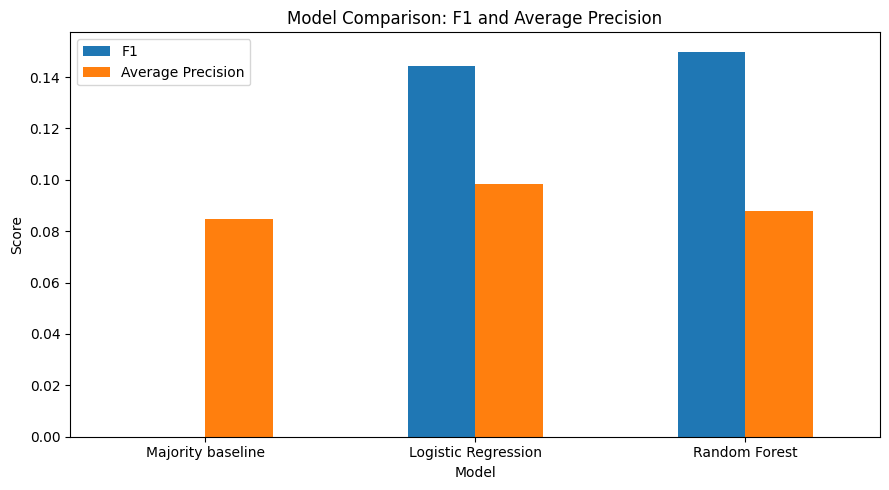

In [96]:
import matplotlib.pyplot as plt

artifact_metrics = final_results[
    ["Model", "F1", "Average Precision"]
].set_index("Model")

ax = artifact_metrics.plot(
    kind="bar",
    figsize=(9, 5)
)

ax.set_title("Model Comparison: F1 and Average Precision")
ax.set_ylabel("Score")
ax.set_xlabel("Model")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

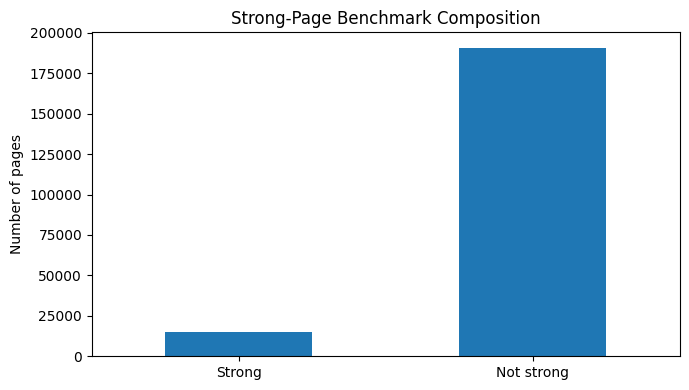

In [97]:
benchmark_counts = pd.Series({
    "Strong": int(full_df["is_strong"].sum()),
    "Not strong": int((~full_df["is_strong"]).sum())
})

ax = benchmark_counts.plot(
    kind="bar",
    figsize=(7, 4)
)

ax.set_title("Strong-Page Benchmark Composition")
ax.set_ylabel("Number of pages")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Reproducibility

The notebook uses a fixed random seed of 42. The analysis is designed to run from a fresh environment using the same FlyRank dataset release and `ranking_lifecycle` subset. The pipeline includes data loading, target construction, feature selection, grouped validation, preprocessing, model training, threshold selection, evaluation, and recommendation generation.

In [98]:
import importlib.metadata as metadata

packages_to_report = [
    "pandas",
    "numpy",
    "datasets",
    "scikit-learn",
    "matplotlib",
]

print("Environment versions:")

for package in packages_to_report:
    try:
        print(
            f"{package}: "
            f"{metadata.version(package)}"
        )
    except metadata.PackageNotFoundError:
        print(f"{package}: not installed")

Environment versions:
pandas: 2.2.2
numpy: 2.5.2
datasets: 4.0.0
scikit-learn: 1.6.1
matplotlib: 3.10.0


In [99]:
print("Random seed:", RANDOM_STATE)
print("Dataset subset: ranking_lifecycle")
print("Split: StratifiedGroupKFold")
print("Number of folds:", 5)

Random seed: 42
Dataset subset: ranking_lifecycle
Split: StratifiedGroupKFold
Number of folds: 5


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.